In [1]:
import os
import time
import sys
sys.path.append("..")

import numpy as np

import ssptools
from astropy.coordinates import SkyCoord
import rocks

import matplotlib.pyplot as plt

from fink_utils.sso.spins import (rotation_phase, subobserver_longitude)

In [65]:
# Simulation set
target = 87
nbd = 100
step = 10

In [66]:
# Retrieve target properties
sc = rocks.Rock(target)
P_s = sc.spin[0].period.value / 24
ra0 = np.radians(sc.spin[0].RA0.value)
de0 = np.radians(sc.spin[0].DEC0.value)

ra0_alt = ( (ra0+np.pi) % (2*np.pi))
de0_alt = -de0

t0 = sc.spin[0].t0.value
Wp = sc.spin[0].Wp.value

In [67]:
# P_s = 8.6/24
# Wp = 2*np.pi/P_s

In [68]:
print(f'Spin    : {np.degrees(ra0):5.1f} {np.degrees(de0):5.1f}')
print(f'Spin alt: {np.degrees(ra0_alt):5.1f} {np.degrees(de0_alt):5.1f}')

print(f'Period  : {P_s:5.1f} days')
print(f'T0      : {t0} MJD')
print(f'Wp      : {Wp:5.1f} rad/day')

Spin    : 348.2  82.9
Spin alt: 168.2 -82.9
Period  :   0.2 days
T0      : 2451545.0 MJD
Wp      : 1666.8 rad/day


In [69]:
# Ephemerides
ephem = ssptools.ephemcc( target, 'now', nbd=nbd, step=step)
coord = SkyCoord(
    ra=ephem.RA, dec=ephem.DEC, unit=("hour", "deg")
)
ephem['ra'] = coord.ra.rad
ephem['dec'] = coord.dec.rad

In [70]:
# Compute the sub-observer longitude for 2 opposite spins
W = rotation_phase(ephem.Date, 0, Wp, t0)
sep_l = subobserver_longitude(ephem.ra, ephem.dec, ra0, de0, W)
sep_l_alt = subobserver_longitude(ephem.ra, ephem.dec, ra0_alt, de0_alt, W)

Text(0, 0.5, 'Difference of SEP longitude (deg)')

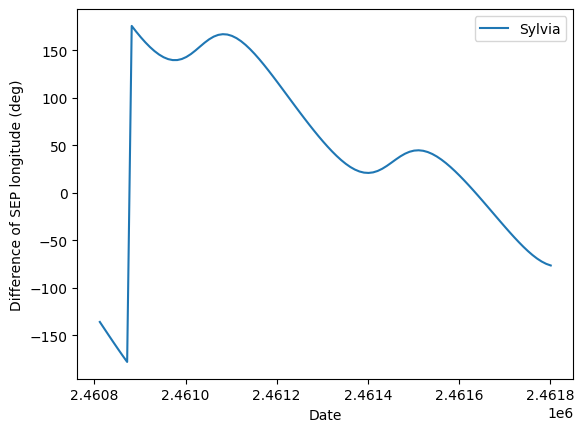

In [71]:
fig, ax = plt.subplots()

ax.plot(ephem.Date, np.degrees(sep_l-sep_l_alt), label=sc.name)

ax.legend()
ax.set_xlabel('Date')
ax.set_ylabel('Difference of SEP longitude (deg)')